✅ Dashboard generated and saved as cpi_nowcasting_dashboard.png


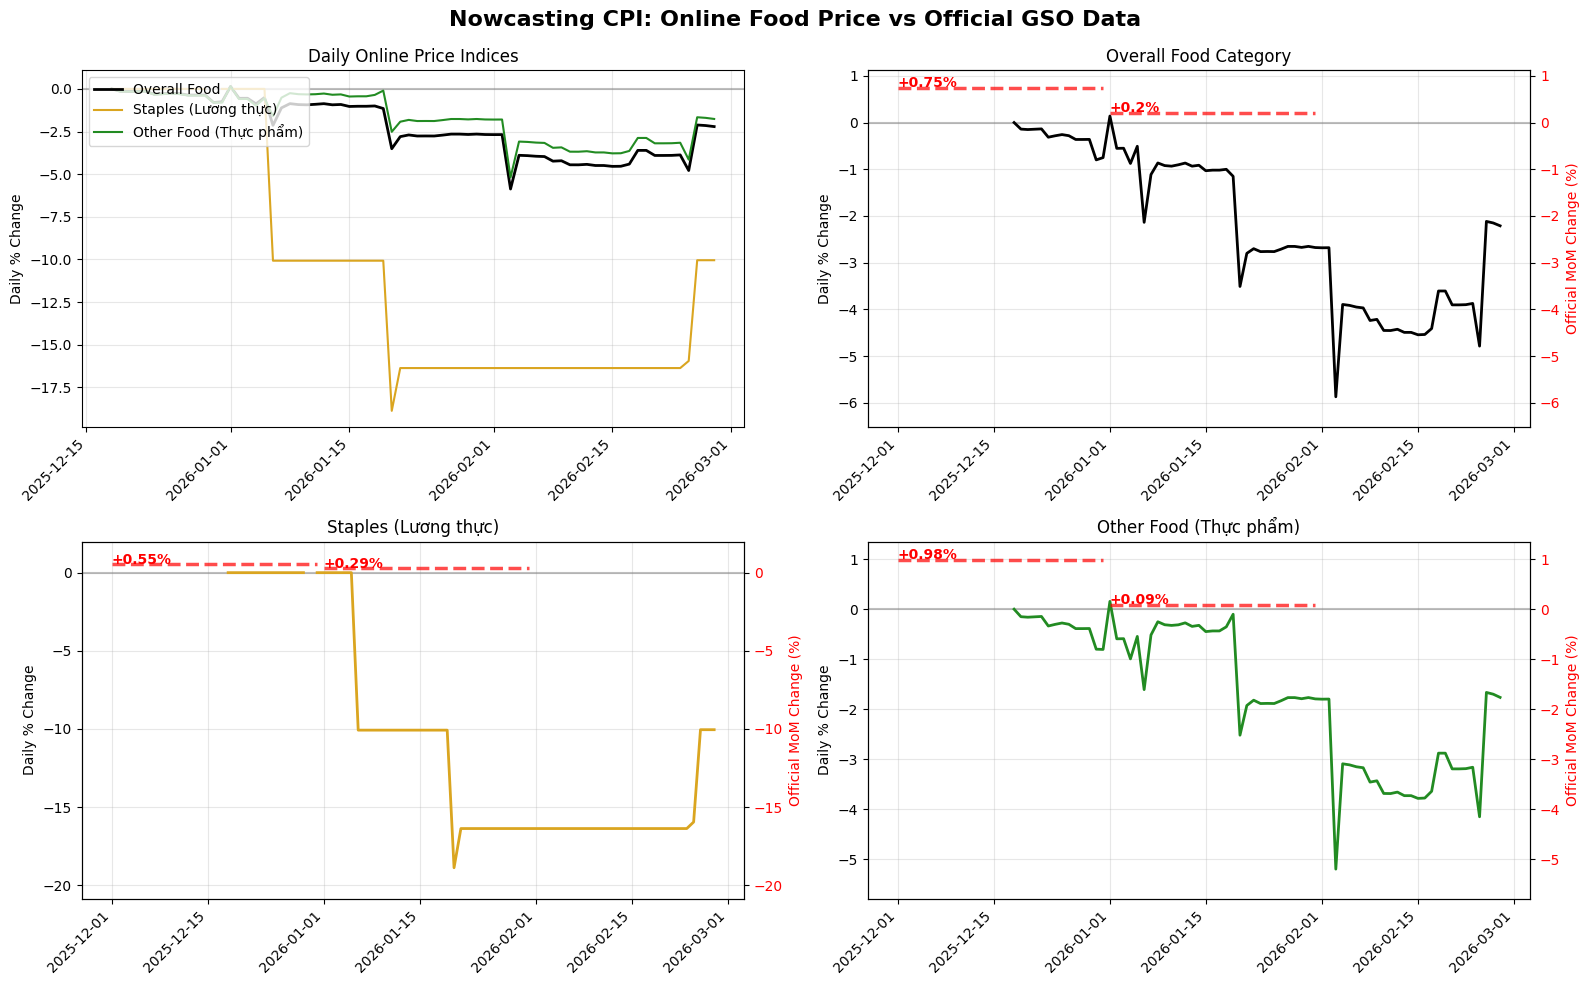

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path

# --- Configuration ---
CSV_PATH = 'overall_daily_average_index.csv'
JSON_PATH = 'official_cpi.json'

def load_data():
    # Load Daily Index Data
    df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    
    # CONVERSION: Convert Jevons Index (base 1.0) to Daily Percentage Change (%)
    cols_to_convert = ['overall_average_index', 'staples_average_index', 'other_food_average_index']
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = (df[col] - 1) * 100
            
    # Load Official CPI Data
    with open(JSON_PATH, 'r') as f:
        cpi_data = json.load(f)['official_cpi_mom_pct']
        
    return df, cpi_data

def align_axes(ax1, ax2):
    """Forces both axes to have the exact same scale and 0-mark."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    
    padding = (final_max - final_min) * 0.05
    
    ax1.set_ylim(final_min - padding, final_max + padding)
    ax2.set_ylim(final_min - padding, final_max + padding)

def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Adds horizontal lines spanning the exact calendar month for official MoM CPI."""
    ax2 = ax.twinx()
    
    for month_str, values in cpi_data.items():
        # Force the line to start exactly on the 1st and end on the last day of the month
        start_date = pd.to_datetime(f"{month_str}-01")
        end_date = start_date + pd.offsets.MonthEnd(1)
        
        mom_pct = values[category_key]
        
        ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date, 
                   color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                   label=f'Official {month_str} ({mom_pct}%)')
        
        ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')

    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    return ax2

def plot_dashboard():
    df, cpi_data = load_data()
    
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Nowcasting CPI: Online Food Price vs Official GSO Data', fontsize=16, fontweight='bold')
    
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    
    # Helper to draw a visible 0 baseline
    def draw_zero_line(ax):
        ax.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)

    # ==========================================
    # CHART 1: All Online Indices Combined
    # ==========================================
    ax1 = axs[0, 0]
    draw_zero_line(ax1)
    ax1.plot(df['date'], df['overall_average_index'], label='Overall Food', color='black', linewidth=2)
    
    if 'staples_average_index' in df.columns:
        ax1.plot(df['date'], df['staples_average_index'], label='Staples (Lương thực)', color='goldenrod')
    if 'other_food_average_index' in df.columns:
        ax1.plot(df['date'], df['other_food_average_index'], label='Other Food (Thực phẩm)', color='forestgreen')
        
    ax1.set_title('Daily Online Price Indices')
    ax1.set_ylabel('Daily % Change')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # ==========================================
    # CHART 2: Overall Index vs Official
    # ==========================================
    ax2 = axs[0, 1]
    draw_zero_line(ax2)
    ax2.plot(df['date'], df['overall_average_index'], label='Daily % Change', color='black', linewidth=2)
    ax2.set_title('Overall Food Category')
    ax2.set_ylabel('Daily % Change')
    ax2_twin = add_official_cpi_lines(ax2, cpi_data, 'overall_food', 'red')
    align_axes(ax2, ax2_twin)
    ax2.grid(True, alpha=0.3)

    # ==========================================
    # CHART 3: Staples vs Official
    # ==========================================
    ax3 = axs[1, 0]
    draw_zero_line(ax3)
    if 'staples_average_index' in df.columns:
        ax3.plot(df['date'], df['staples_average_index'], label='Daily % Change', color='goldenrod', linewidth=2)
        ax3.set_title('Staples (Lương thực)')
        ax3.set_ylabel('Daily % Change')
        ax3_twin = add_official_cpi_lines(ax3, cpi_data, 'staples', 'red')
        align_axes(ax3, ax3_twin)
    else:
        ax3.text(0.5, 0.5, 'Staples data missing', ha='center', va='center')
    ax3.grid(True, alpha=0.3)

    # ==========================================
    # CHART 4: Thực phẩm vs Official
    # ==========================================
    ax4 = axs[1, 1]
    draw_zero_line(ax4)
    if 'other_food_average_index' in df.columns:
        ax4.plot(df['date'], df['other_food_average_index'], label='Daily % Change', color='forestgreen', linewidth=2)
        ax4.set_title('Other Food (Thực phẩm)')
        ax4.set_ylabel('Daily % Change')
        ax4_twin = add_official_cpi_lines(ax4, cpi_data, 'thuc_pham', 'red')
        align_axes(ax4, ax4_twin)
    else:
        ax4.text(0.5, 0.5, 'Other Food data missing', ha='center', va='center')
    ax4.grid(True, alpha=0.3)

    # Polish formatting
    for ax in axs.flat:
        ax.xaxis.set_major_formatter(date_fmt)
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92) 
    
    # Save and display
    output_img = 'cpi_nowcasting_dashboard.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Dashboard generated and saved as {output_img}")
    plt.show()

if __name__ == "__main__":
    plot_dashboard()

✅ Staples MoM visualization generated and saved as staples_mom_comparison.png


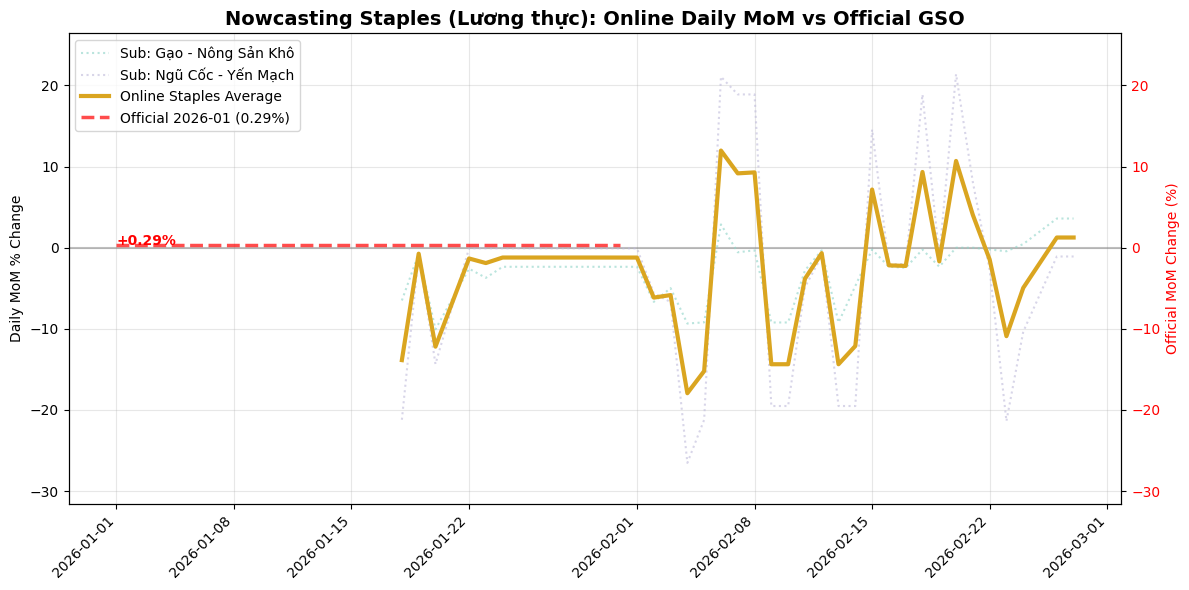

In [18]:


# --- Configuration ---
CSV_PATH = '/Users/my/Online Food Price/Dry_Food/mom_price_change.csv'
JSON_PATH = 'official_cpi.json'

def load_data():
    # Load Daily Index Data
    df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    
    # Identify the staple columns generated by your previous script
    staple_cols = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
    available_cols = [c for c in staple_cols if c in df.columns]
    
    # Calculate the average to represent the overall "Staples" category
    if available_cols:
        df['staples_average'] = df[available_cols].mean(axis=1)
    
    # CONVERSION: Convert Jevons Index (base 1.0) to Daily Percentage Change (%)
    # E.g., a ratio of 1.02 becomes +2.0%
    cols_to_convert = available_cols + ['staples_average']
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = (df[col] - 1) * 100
            
    # Load Official CPI Data
    with open(JSON_PATH, 'r') as f:
        cpi_data = json.load(f)['official_cpi_mom_pct']
        
    return df, cpi_data, available_cols

def align_axes(ax1, ax2):
    """Forces both axes to have the exact same scale and 0-mark."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    
    padding = (final_max - final_min) * 0.05
    
    ax1.set_ylim(final_min - padding, final_max + padding)
    ax2.set_ylim(final_min - padding, final_max + padding)

def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Adds horizontal lines spanning the exact calendar month for official MoM CPI."""
    ax2 = ax.twinx()
    
    for month_str, values in cpi_data.items():
        # --- CHANGE HERE: Skip December 2025 ---
        if month_str == '2025-12':
            continue
            
        start_date = pd.to_datetime(f"{month_str}-01")
        end_date = start_date + pd.offsets.MonthEnd(1)
        mom_pct = values.get(category_key)
        
        if mom_pct is not None:
            ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date, 
                       color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                       label=f'Official {month_str} ({mom_pct}%)')
            
            ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')

    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    return ax2

def plot_staples():
    df, cpi_data, available_cols = load_data()
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    plt.title('Nowcasting Staples (Lương thực): Online Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
    
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    
    # Draw a visible 0 baseline
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)

    # Plot the individual subcategories in the background (lighter colors)
    colors = ['#8dd3c7', '#bebada']
    for idx, col in enumerate(available_cols):
        # Using dropna() so the plot doesn't break if a specific day is missing data
        valid_data = df.dropna(subset=[col])
        ax1.plot(valid_data['date'], valid_data[col], 
                 label=f'Sub: {col}', color=colors[idx % len(colors)], 
                 linewidth=1.5, alpha=0.6, linestyle=':')

    # Plot the combined Staples Average boldly in the foreground
    if 'staples_average' in df.columns:
        valid_avg = df.dropna(subset=['staples_average'])
        ax1.plot(valid_avg['date'], valid_avg['staples_average'], 
                 label='Online Staples Average', color='goldenrod', linewidth=3)
        
    ax1.set_ylabel('Daily MoM % Change')
    ax1.grid(True, alpha=0.3)
    
    # Add the official CPI line for 'staples'
    ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'staples', 'red')
    
    # Synchronize the left and right Y-axes
    align_axes(ax1, ax2_twin)

    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Polish formatting
    ax1.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    
    # Save and display
    output_img = 'staples_mom_comparison.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Staples MoM visualization generated and saved as {output_img}")
    plt.show()

if __name__ == "__main__":
    plot_staples()

✅ Staples MoM visualization generated and saved as staples_mom_comparison.png


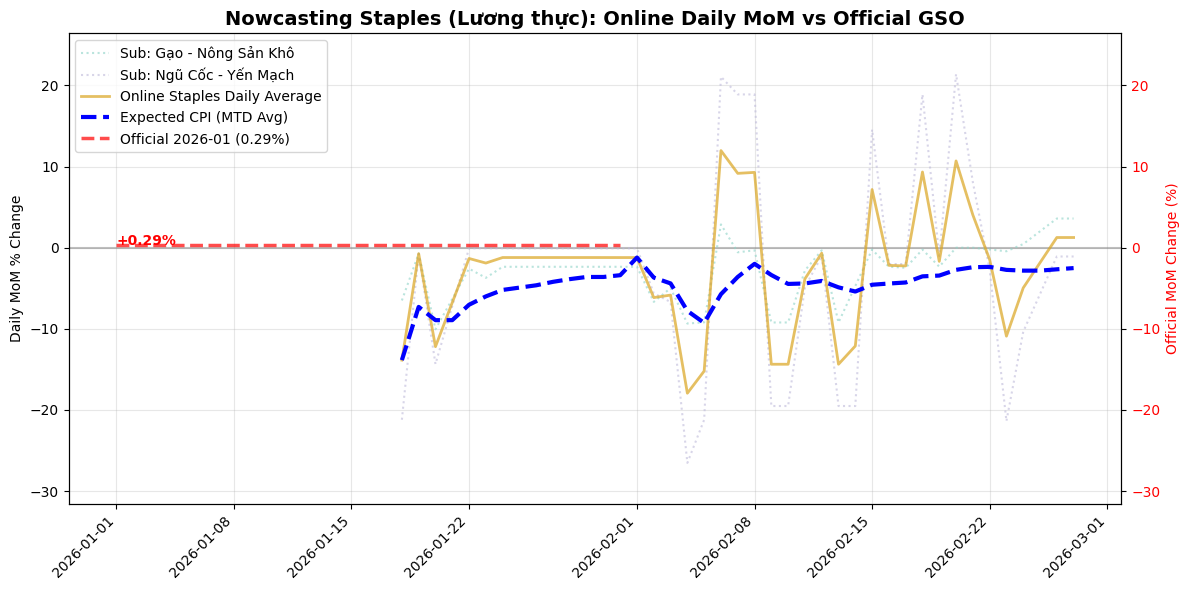

In [17]:

# --- Configuration ---
CSV_PATH = '/Users/my/Online Food Price/Dry_Food/mom_price_change.csv'
JSON_PATH = 'official_cpi.json'

def load_data():
    # Load Daily Index Data
    df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    
    # Identify the staple columns generated by your previous script
    staple_cols = ['Gạo - Nông Sản Khô', 'Ngũ Cốc - Yến Mạch']
    available_cols = [c for c in staple_cols if c in df.columns]
    
    # Calculate the average to represent the overall "Staples" category
    if available_cols:
        df['staples_average'] = df[available_cols].mean(axis=1)
    
    # CONVERSION: Convert Jevons Index (base 1.0) to Daily Percentage Change (%)
    # E.g., a ratio of 1.02 becomes +2.0%
    cols_to_convert = available_cols + ['staples_average']
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = (df[col] - 1) * 100
            
    # CALCULATE EXPECTED CPI: Month-to-Date (MTD) cumulative average
    if 'staples_average' in df.columns:
        # Group by Year-Month and calculate the expanding (cumulative) mean
        df['expected_cpi'] = df.groupby(df['date'].dt.to_period('M'))['staples_average'].transform(lambda x: x.expanding().mean())

    # Load Official CPI Data
    with open(JSON_PATH, 'r') as f:
        cpi_data = json.load(f)['official_cpi_mom_pct']
        
    return df, cpi_data, available_cols

def align_axes(ax1, ax2):
    """Forces both axes to have the exact same scale and 0-mark."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    
    padding = (final_max - final_min) * 0.05
    
    ax1.set_ylim(final_min - padding, final_max + padding)
    ax2.set_ylim(final_min - padding, final_max + padding)

def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Adds horizontal lines spanning the exact calendar month for official MoM CPI."""
    ax2 = ax.twinx()
    
    for month_str, values in cpi_data.items():
        # --- CHANGE HERE: Skip December 2025 ---
        if month_str == '2025-12':
            continue
            
        start_date = pd.to_datetime(f"{month_str}-01")
        end_date = start_date + pd.offsets.MonthEnd(1)
        mom_pct = values.get(category_key)
        
        if mom_pct is not None:
            ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date, 
                       color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                       label=f'Official {month_str} ({mom_pct}%)')
            
            ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')

    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    return ax2

def plot_staples():
    df, cpi_data, available_cols = load_data()
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    plt.title('Nowcasting Staples (Lương thực): Online Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
    
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    
    # Draw a visible 0 baseline
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)

    # Plot the individual subcategories in the background (lighter colors)
    colors = ['#8dd3c7', '#bebada']
    for idx, col in enumerate(available_cols):
        # Using dropna() so the plot doesn't break if a specific day is missing data
        valid_data = df.dropna(subset=[col])
        ax1.plot(valid_data['date'], valid_data[col], 
                 label=f'Sub: {col}', color=colors[idx % len(colors)], 
                 linewidth=1.5, alpha=0.6, linestyle=':')

    # Plot the combined Staples Average boldly in the foreground
    if 'staples_average' in df.columns:
        valid_avg = df.dropna(subset=['staples_average'])
        ax1.plot(valid_avg['date'], valid_avg['staples_average'], 
                 label='Online Staples Daily Average', color='goldenrod', linewidth=2, alpha=0.7)
                 
    # Plot the Expected CPI (Month-to-Date Average)
    if 'expected_cpi' in df.columns:
        valid_expected = df.dropna(subset=['expected_cpi'])
        ax1.plot(valid_expected['date'], valid_expected['expected_cpi'], 
                 label='Expected CPI (MTD Avg)', color='blue', linewidth=3, linestyle='--')
        
    ax1.set_ylabel('Daily MoM % Change')
    ax1.grid(True, alpha=0.3)
    
    # Add the official CPI line for 'staples'
    ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'staples', 'red')
    
    # Synchronize the left and right Y-axes
    align_axes(ax1, ax2_twin)

    # Combine legends from both axes safely
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Polish formatting
    ax1.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    
    # Save and display
    output_img = 'staples_mom_comparison.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Staples MoM visualization generated and saved as {output_img}")
    plt.show()

if __name__ == "__main__":
    plot_staples()

✅ Other Food MoM visualization generated and saved as other_food_mom_comparison.png


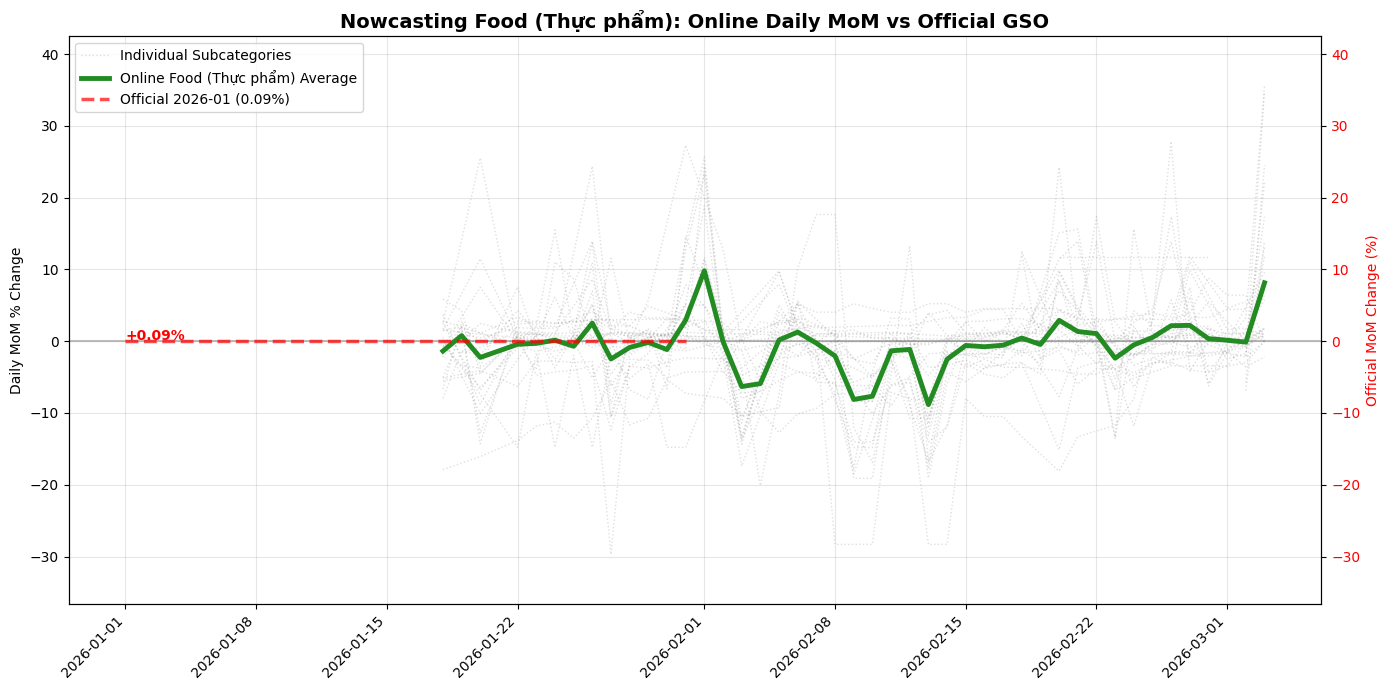

In [16]:
# --- Configuration ---
CSV_PATH = '/Users/my/Online Food Price/other_food_mom_change.csv'
JSON_PATH = 'official_cpi.json'

def load_data():
    # Load Daily Index Data
    df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    
    # Identify the subcategory columns (everything except 'date' and the average)
    available_cols = [c for c in df.columns if c not in ['date', 'other_food_average']]
    
    # CONVERSION: Convert Jevons Index (base 1.0) to Daily Percentage Change (%)
    cols_to_convert = available_cols + ['other_food_average']
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = (df[col] - 1) * 100
            
    # Load Official CPI Data
    with open(JSON_PATH, 'r') as f:
        cpi_data = json.load(f)['official_cpi_mom_pct']
        
    return df, cpi_data, available_cols

def align_axes(ax1, ax2):
    """Forces both axes to have the exact same scale and 0-mark."""
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    
    padding = (final_max - final_min) * 0.05
    
    ax1.set_ylim(final_min - padding, final_max + padding)
    ax2.set_ylim(final_min - padding, final_max + padding)

def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Adds horizontal lines spanning the exact calendar month for official MoM CPI."""
    ax2 = ax.twinx()
    
    for month_str, values in cpi_data.items():
        # --- CHANGE HERE: Skip December 2025 ---
        if month_str == '2025-12':
            continue
            
        start_date = pd.to_datetime(f"{month_str}-01")
        end_date = start_date + pd.offsets.MonthEnd(1)
        mom_pct = values.get(category_key)
        
        if mom_pct is not None:
            ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date, 
                       color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                       label=f'Official {month_str} ({mom_pct}%)')
            
            ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')

    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    
    return ax2

def plot_other_food():
    df, cpi_data, available_cols = load_data()
    
    fig, ax1 = plt.subplots(figsize=(14, 7))
    plt.title('Nowcasting Food (Thực phẩm): Online Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
    
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    
    # Draw a visible 0 baseline
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)

    # Plot the individual subcategories in the background (faint gray)
    for idx, col in enumerate(available_cols):
        valid_data = df.dropna(subset=[col])
        # Only add the label to the legend once to avoid clutter
        label = 'Individual Subcategories' if idx == 0 else "_nolegend_"
        ax1.plot(valid_data['date'], valid_data[col], 
                 label=label, color='gray', 
                 linewidth=1.0, alpha=0.25, linestyle=':')

    # Plot the combined Other Food Average boldly in the foreground
    if 'other_food_average' in df.columns:
        valid_avg = df.dropna(subset=['other_food_average'])
        ax1.plot(valid_avg['date'], valid_avg['other_food_average'], 
                 label='Online Food (Thực phẩm) Average', color='forestgreen', linewidth=3.5)
        
    ax1.set_ylabel('Daily MoM % Change')
    ax1.grid(True, alpha=0.3)
    
    # Add the official CPI line specifically for 'thuc_pham'
    ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'thuc_pham', 'red')
    
    # Synchronize the left and right Y-axes
    align_axes(ax1, ax2_twin)

    # Combine legends from both axes safely
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # Polish formatting
    ax1.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    
    # Save and display
    output_img = 'other_food_mom_comparison.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Other Food MoM visualization generated and saved as {output_img}")
    plt.show()

if __name__ == "__main__":
    plot_other_food()

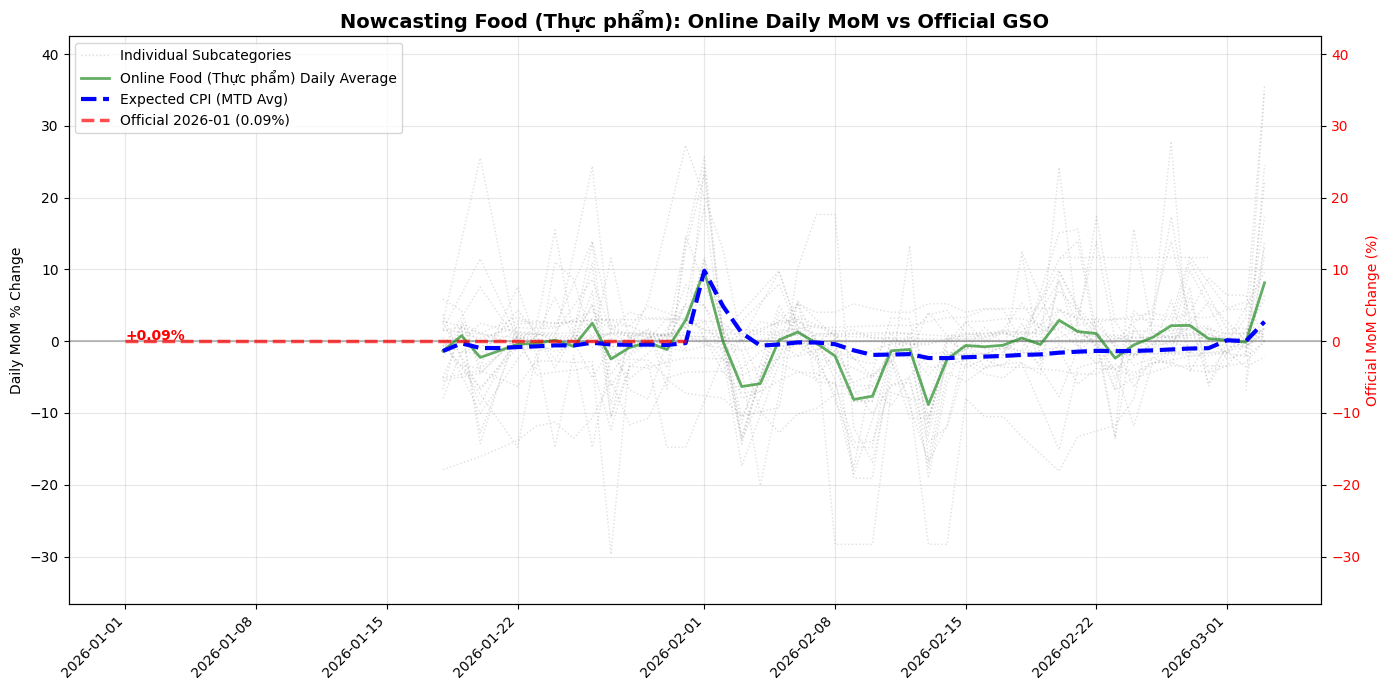

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path

# --- Configuration ---
CSV_PATH = '/Users/my/Online Food Price/other_food_mom_change.csv'
JSON_PATH = 'official_cpi.json'

def load_data():
    df = pd.read_csv(CSV_PATH, parse_dates=['date'])
    available_cols = [c for c in df.columns if c not in ['date', 'other_food_average']]
    
    cols_to_convert = available_cols + ['other_food_average']
    for col in cols_to_convert:
        if col in df.columns:
            df[col] = (df[col] - 1) * 100
            
    if 'other_food_average' in df.columns:
        df['expected_cpi'] = df.groupby(df['date'].dt.to_period('M'))['other_food_average'].transform(lambda x: x.expanding().mean())

    with open(JSON_PATH, 'r') as f:
        cpi_data = json.load(f)['official_cpi_mom_pct']
        
    return df, cpi_data, available_cols

def align_axes(ax1, ax2):
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()
    final_min = min(y1_min, y2_min)
    final_max = max(y1_max, y2_max)
    padding = (final_max - final_min) * 0.05
    ax1.set_ylim(final_min - padding, final_max + padding)
    ax2.set_ylim(final_min - padding, final_max + padding)

def add_official_cpi_lines(ax, cpi_data, category_key, color):
    """Adds horizontal lines, excluding December 2025."""
    ax2 = ax.twinx()
    
    for month_str, values in cpi_data.items():
        # --- CHANGE HERE: Skip December 2025 ---
        if month_str == '2025-12':
            continue
            
        start_date = pd.to_datetime(f"{month_str}-01")
        end_date = start_date + pd.offsets.MonthEnd(1)
        mom_pct = values.get(category_key)
        
        if mom_pct is not None:
            ax2.hlines(y=mom_pct, xmin=start_date, xmax=end_date, 
                       color=color, linestyle='--', linewidth=2.5, alpha=0.7,
                       label=f'Official {month_str} ({mom_pct}%)')
            
            ax2.text(start_date, mom_pct + 0.02, f'+{mom_pct}%', color=color, fontweight='bold')

    ax2.set_ylabel('Official MoM Change (%)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    return ax2

def plot_other_food():
    df, cpi_data, available_cols = load_data()
    fig, ax1 = plt.subplots(figsize=(14, 7))
    plt.title('Nowcasting Food (Thực phẩm): Online Daily MoM vs Official GSO', fontsize=14, fontweight='bold')
    
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, alpha=0.5)

    for idx, col in enumerate(available_cols):
        valid_data = df.dropna(subset=[col])
        label = 'Individual Subcategories' if idx == 0 else "_nolegend_"
        ax1.plot(valid_data['date'], valid_data[col], 
                 label=label, color='gray', linewidth=1.0, alpha=0.25, linestyle=':')

    if 'other_food_average' in df.columns:
        valid_avg = df.dropna(subset=['other_food_average'])
        ax1.plot(valid_avg['date'], valid_avg['other_food_average'], 
                 label='Online Food (Thực phẩm) Daily Average', color='forestgreen', linewidth=2, alpha=0.7)
                 
    if 'expected_cpi' in df.columns:
        valid_expected = df.dropna(subset=['expected_cpi'])
        ax1.plot(valid_expected['date'], valid_expected['expected_cpi'], 
                 label='Expected CPI (MTD Avg)', color='blue', linewidth=3, linestyle='--')
        
    ax1.set_ylabel('Daily MoM % Change')
    ax1.grid(True, alpha=0.3)
    
    ax2_twin = add_official_cpi_lines(ax1, cpi_data, 'thuc_pham', 'red')
    align_axes(ax1, ax2_twin)

    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2_twin.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    ax1.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_other_food()